# DATA PREPROCESSING & ANALYSIS(EDA)

## 1.Setup & load encoded dataset

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("fivethirtyeight")
sns.set_palette("viridis")

In [3]:
dataset = pd.read_csv('clean_dataset.csv', index_col = 0)
print("Shape:",dataset.shape)

Shape: (10000, 15)


In [4]:
fraud= dataset[dataset['FraudFlag']==1]
valid= dataset[dataset['FraudFlag']==0]
print("Number of fraud data :", len(fraud))
print("Number of valid data :", len(valid))

Number of fraud data : 965
Number of valid data : 9035


In [5]:
dataset.head()

,trans_hour,trans_day,trans_month,Amount,MerchantCategory,TransactionType,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,BankName,Amount_to_Avg_Ratio,FraudFlag
0,3,22,1,8589.00,1,0,670.31,5,0,1,0,2,1,12.813474,1
1,13,1,7,9090.54,1,0,7265.96,3,0,1,0,2,3,1.251113,0
2,5,2,4,8814.41,1,1,8750.89,3,1,0,1,3,3,1.007259,0
3,16,14,6,3971.25,4,1,8348.14,1,1,1,0,4,5,0.475705,0
4,3,16,7,4376.74,3,0,1719.74,1,1,1,0,0,3,2.545001,0


## 2. Basic health check & info

In [6]:
print("\n Basic Info:")
print(dataset.info())
print("\n Missing values:")
print(dataset.isnull().sum())


 Basic Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trans_hour            10000 non-null  int64  
 1   trans_day             10000 non-null  int64  
 2   trans_month           10000 non-null  int64  
 3   Amount                10000 non-null  float64
 4   MerchantCategory      10000 non-null  int64  
 5   TransactionType       10000 non-null  int64  
 6   AvgTransactionAmount  10000 non-null  float64
 7   TransactionFrequency  10000 non-null  int64  
 8   UnusualLocation       10000 non-null  int64  
 9   UnusualAmount         10000 non-null  int64  
 10  NewDevice             10000 non-null  int64  
 11  FailedAttempts        10000 non-null  int64  
 12  BankName              10000 non-null  int64  
 13  Amount_to_Avg_Ratio   10000 non-null  float64
 14  FraudFlag             10000 non-null  int64  
dtypes: float64(

# EXPLORATORY DATA ANALYSIS 

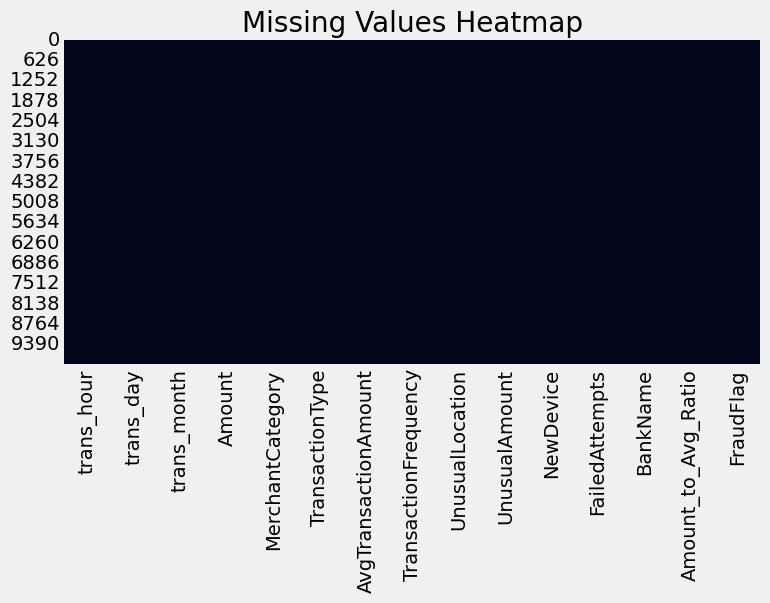

In [7]:
# MISSING VALUES CHECK 
plt.figure(figsize=(8,4))
sns.heatmap(dataset.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show() # no missing values found

## 3. Fraud vs Valid Distribution

In [8]:
print("Class counts:")
print(dataset['FraudFlag'].value_counts())
print("\nClass percentage (%):")
print((dataset['FraudFlag'].value_counts(normalize=True)*100).round(2))

Class counts:
FraudFlag
0    9035
1     965
Name: count, dtype: int64

Class percentage (%):
FraudFlag
0    90.35
1     9.65
Name: proportion, dtype: float64


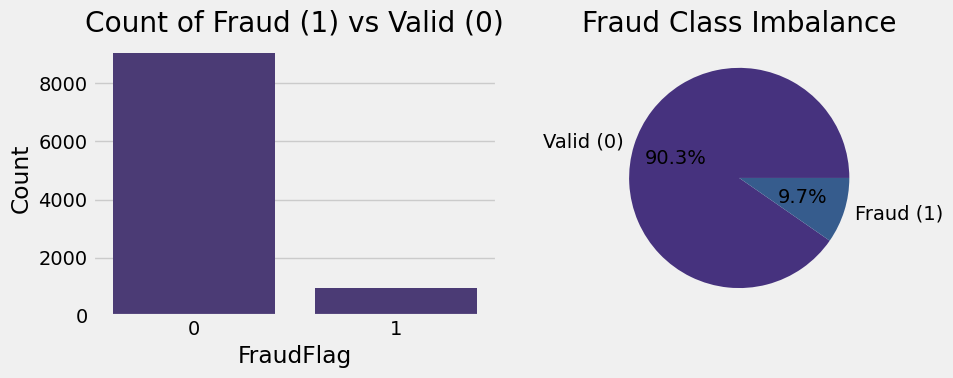

In [9]:

ig, ax = plt.subplots(1, 2, figsize=(10,4))

# Bar plot
sns.countplot(x='FraudFlag', data=dataset, ax=ax[0])
ax[0].set_title("Count of Fraud (1) vs Valid (0)")
ax[0].set_xlabel("FraudFlag")
ax[0].set_ylabel("Count")

# Pie chart
dataset['FraudFlag'].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["Valid (0)", "Fraud (1)"],
    ax=ax[1]
)
ax[1].set_ylabel("")
ax[1].set_title("Fraud Class Imbalance")

plt.tight_layout()
plt.show()

## 4. Amount Distribution (General+By Fraud)

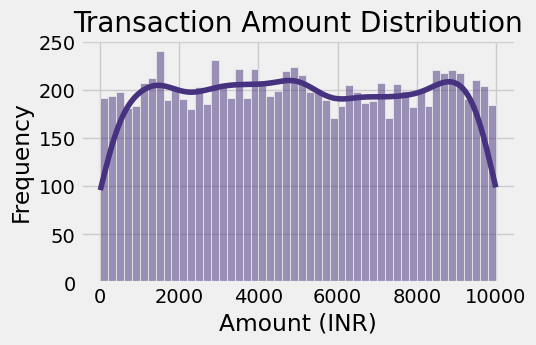

In [10]:
plt.figure(figsize=(5,3))
sns.histplot(dataset['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()

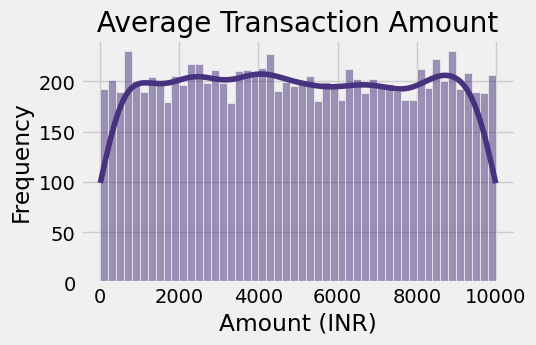

In [11]:
plt.figure(figsize=(5,3))
sns.histplot(dataset['AvgTransactionAmount'], bins=50, kde=True)
plt.title(" Average Transaction Amount ")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()

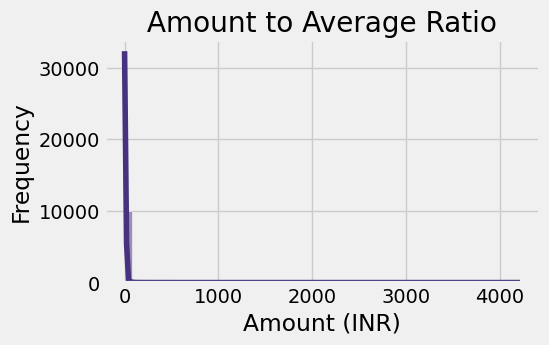

In [12]:
plt.figure(figsize=(5,3))
sns.histplot(dataset['Amount_to_Avg_Ratio'], bins=50, kde=True)
plt.title(" Amount to Average Ratio ")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()

In [13]:
# if 'Amount_to_Avg_Ratio' in dataset.columns:
#     dev_fraud = dataset.groupby( 'Amount_to_Avg_Ratio')['FraudFlag'].mean().reset_index()

#     plt.figure(figsize=(6,4))
#     sns.barplot(x='Amount_to_Avg_Ratio', y='FraudFlag', data=dev_fraud) 
#     title("Fraud Amount to Average Ratio")
#     plt.xlabel("Amount_to_Avg_Ratio ")
#     plt.ylabel("Fraud Rate")
#     plt.show()


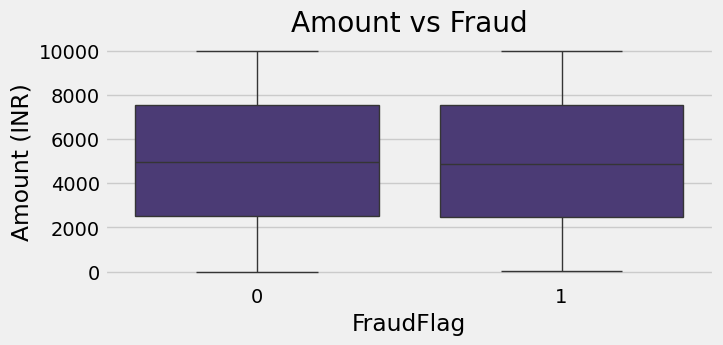

In [14]:
# Fraud vs Non fraud by amount (fraud transactions take place at higher amount)

plt.figure(figsize=(7,3))
sns.boxplot(x='FraudFlag', y='Amount',data=dataset)
plt.title("Amount vs Fraud")
plt.xlabel("FraudFlag")
plt.ylabel("Amount (INR)")
plt.show()

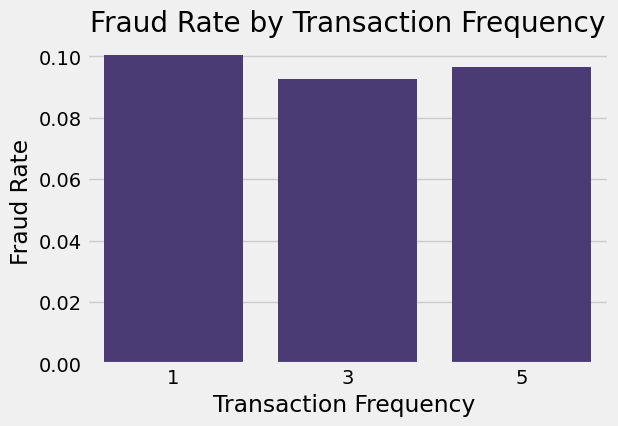

In [15]:
# TRANSACTION FREQUENCY

if 'TransactionFrequency' in dataset.columns:
    dev_fraud = dataset.groupby( 'TransactionFrequency')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='TransactionFrequency', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by Transaction Frequency")
    plt.xlabel("Transaction Frequency ")
    plt.ylabel("Fraud Rate")
    plt.show()


### 5. Time feature 

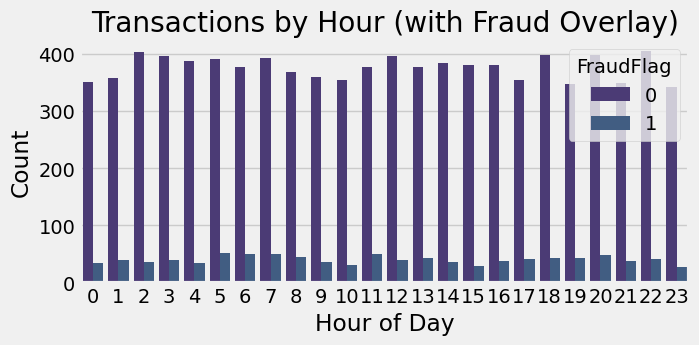

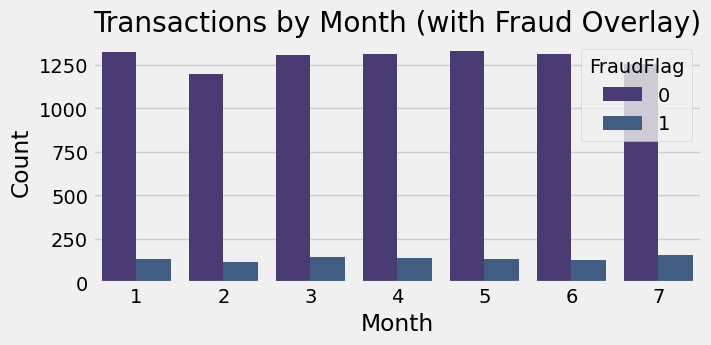

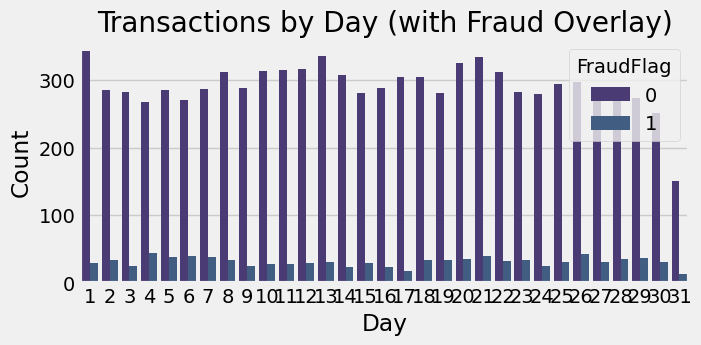

In [16]:
if 'trans_hour' in dataset.columns:
    plt.figure(figsize=(7,3))
    sns.countplot(x='trans_hour', hue='FraudFlag', data=dataset)
    plt.title("Transactions by Hour (with Fraud Overlay)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Count")
    plt.show()

if 'trans_month' in dataset.columns:
    plt.figure(figsize=(7,3))
    sns.countplot(x='trans_month', hue='FraudFlag', data=dataset)
    plt.title("Transactions by Month (with Fraud Overlay)")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.show()


if 'trans_day' in dataset.columns:
    plt.figure(figsize=(7,3))
    sns.countplot(x='trans_day', hue='FraudFlag', data=dataset)
    plt.title("Transactions by Day (with Fraud Overlay)")
    plt.xlabel("Day")
    plt.ylabel("Count")
    plt.show()

### 


6. Categorial Features vs Fraud

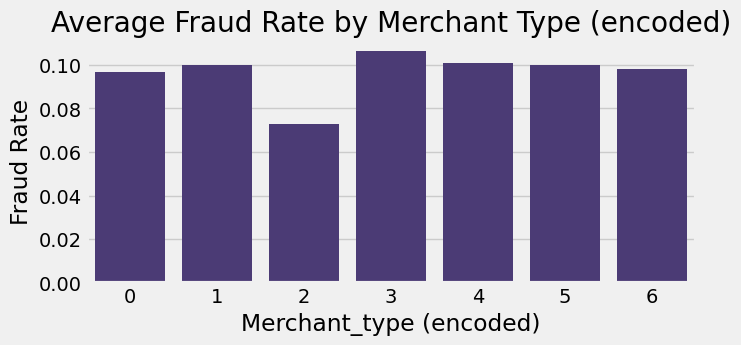

In [17]:
# MERCHANT TYPE FRAUD

if 'MerchantCategory' in dataset.columns:
    mt_fraud = dataset.groupby('MerchantCategory')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(7,3))
    sns.barplot(x='MerchantCategory', y='FraudFlag', data=mt_fraud) # new Merchant type dataframe
    plt.title("Average Fraud Rate by Merchant Type (encoded)")
    plt.xlabel("Merchant_type (encoded)")
    plt.ylabel("Fraud Rate")
    plt.show()

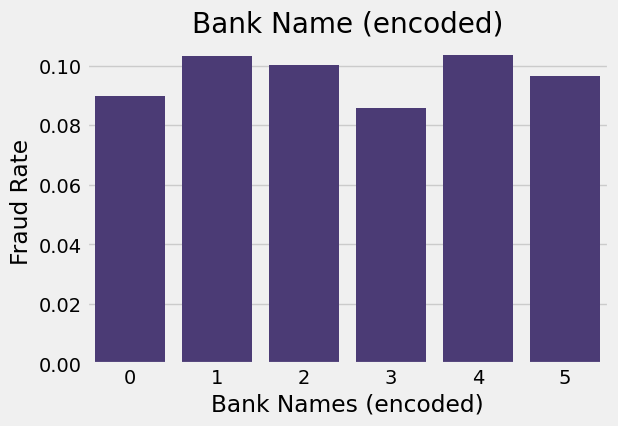

In [18]:
# BANK TYPE FRAUD
if 'BankName' in dataset.columns:
    dev_fraud = dataset.groupby('BankName')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='BankName', y='FraudFlag', data=dev_fraud)# new Device type fraud dataframe 
    plt.title("Bank Name (encoded)")
    plt.xlabel("Bank Names (encoded)")
    plt.ylabel("Fraud Rate")
    plt.show()

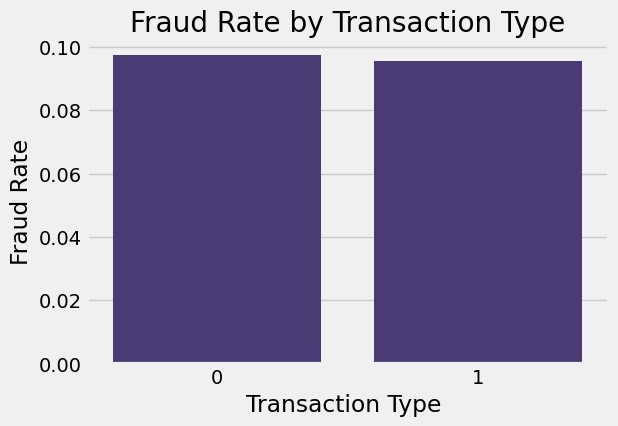

In [19]:
# TRANSACTION TYPE

if 'TransactionType' in dataset.columns:
    dev_fraud = dataset.groupby( 'TransactionType')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='TransactionType', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by Transaction Type")
    plt.xlabel("Transaction Type ")
    plt.ylabel("Fraud Rate")
    plt.show()

### 7. Risk Indicators

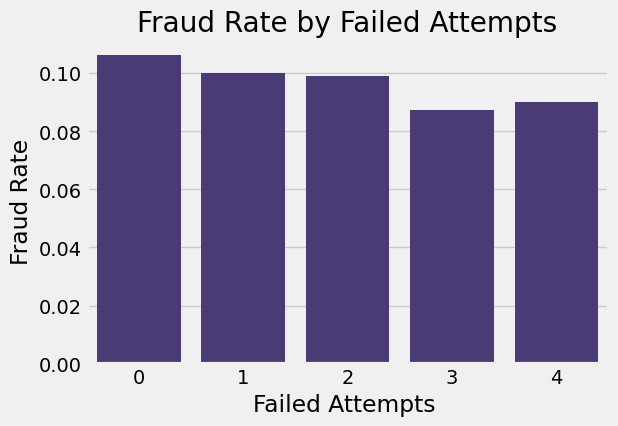

In [20]:
# FAILED ATTEMPTS

if 'FailedAttempts' in dataset.columns:
    dev_fraud = dataset.groupby( 'FailedAttempts')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='FailedAttempts', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by Failed Attempts")
    plt.xlabel("Failed Attempts ")
    plt.ylabel("Fraud Rate")
    plt.show()

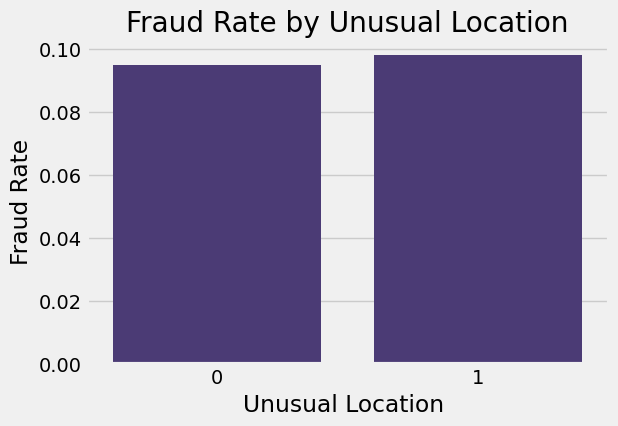

In [21]:
# UNUSUAL LOCATION
if 'UnusualLocation' in dataset.columns:
    dev_fraud = dataset.groupby( 'UnusualLocation')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='UnusualLocation', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by Unusual Location")
    plt.xlabel("Unusual Location ")
    plt.ylabel("Fraud Rate")
    plt.show()

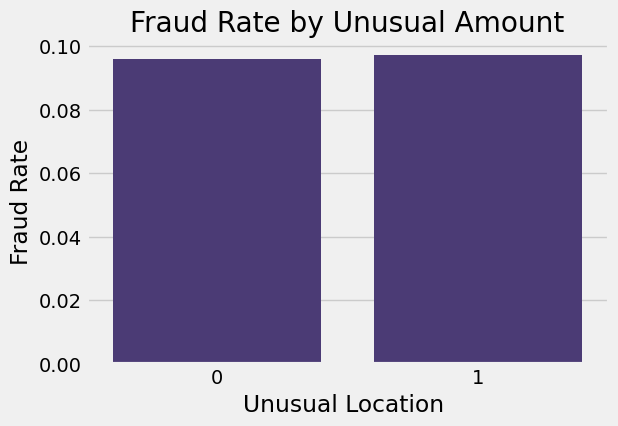

In [22]:
# UNUSUAL AMOUNT

if 'UnusualAmount' in dataset.columns:
    dev_fraud = dataset.groupby( 'UnusualAmount')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='UnusualAmount', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by Unusual Amount")
    plt.xlabel("Unusual Location ")
    plt.ylabel("Fraud Rate")
    plt.show()

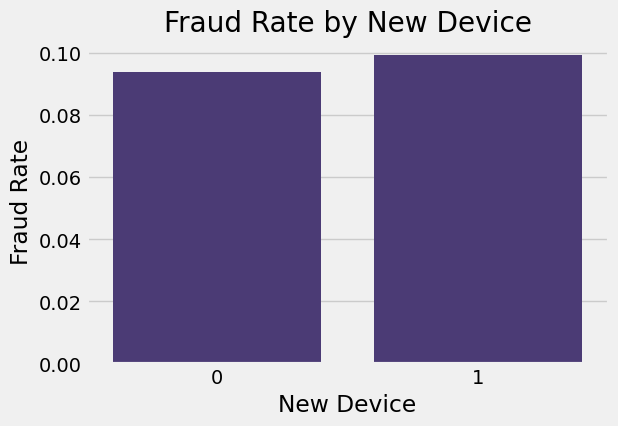

In [23]:
# NEW DEVICE

if 'NewDevice' in dataset.columns:
    dev_fraud = dataset.groupby( 'NewDevice')['FraudFlag'].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(x='NewDevice', y='FraudFlag', data=dev_fraud) 
    plt.title("Fraud Rate by New Device")
    plt.xlabel("New Device")
    plt.ylabel("Fraud Rate")
    plt.show()

### 7. Correlation Heatmap

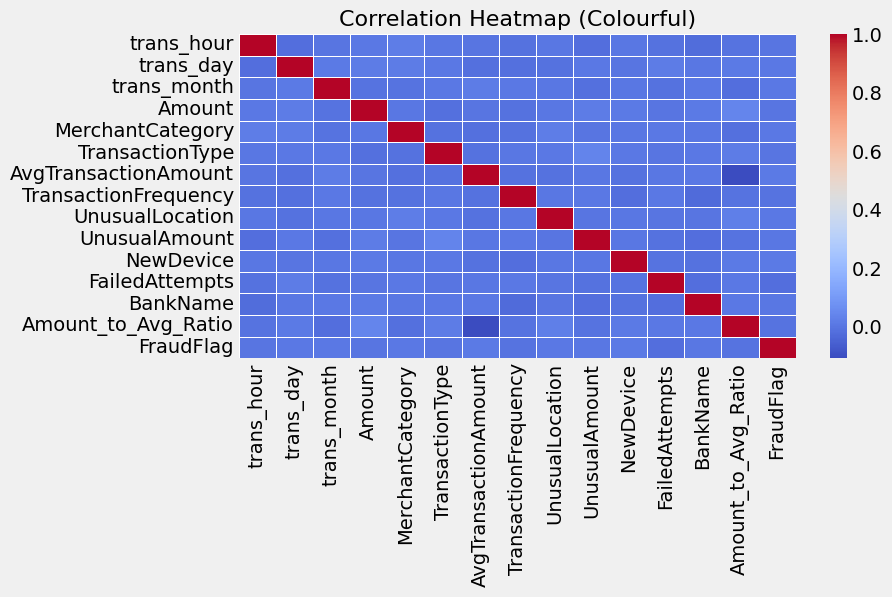

In [24]:
plt.figure(figsize=(8,4))
corr = dataset.corr(numeric_only=True)
sns.heatmap(corr,
            annot=False,
            fmt=".2f",
            cmap="coolwarm",    
            linewidths=0.5,
            linecolor="White")
plt.title("Correlation Heatmap (Colourful)", fontsize=16)
plt.show()

## Final Summary for Data Analysis

Add Summary Statistics + Insights

In [25]:
summary_stats = dataset.groupby('FraudFlag').agg(['mean','median','std'])
print(summary_stats)

          trans_hour                   trans_day                  trans_month  \
                mean median       std       mean median       std        mean   
FraudFlag                                                                       
0          11.455230   11.0  6.895008  15.634754   16.0  8.701891    4.005091   
1          11.384456   11.0  6.802365  15.780311   16.0  9.008838    4.055959   

                                 Amount  ... NewDevice FailedAttempts         \
          median       std         mean  ...       std           mean median   
FraudFlag                                ...                                   
0            4.0  1.992841  5007.234339  ...  0.500018       2.022579    2.0   
1            4.0  2.014722  4978.491233  ...  0.500091       1.919171    2.0   

                     BankName                  Amount_to_Avg_Ratio            \
                std      mean median       std                mean    median   
FraudFlag                        

In [26]:
##Correlation with Target

FraudFlag               1.000000
NewDevice               0.009447
AvgTransactionAmount    0.009161
trans_month             0.007529
MerchantCategory        0.007420
UnusualLocation         0.005538
trans_day               0.004923
BankName                0.003442
UnusualAmount           0.002276
Amount                 -0.002946
trans_hour             -0.003035
TransactionType        -0.003185
TransactionFrequency   -0.005411
Amount_to_Avg_Ratio    -0.005782
FailedAttempts         -0.021551
Name: FraudFlag, dtype: float64


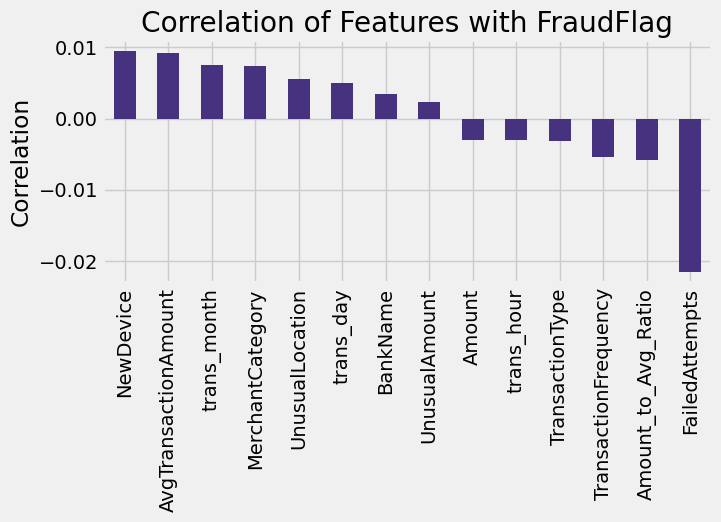

In [27]:
corr_with_target = dataset.corr()['FraudFlag'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(7,3))
corr_with_target.drop('FraudFlag').plot(kind='bar')
plt.title("Correlation of Features with FraudFlag")
plt.ylabel("Correlation")
plt.show()


In [28]:
##Statistical Comparison Between Classes

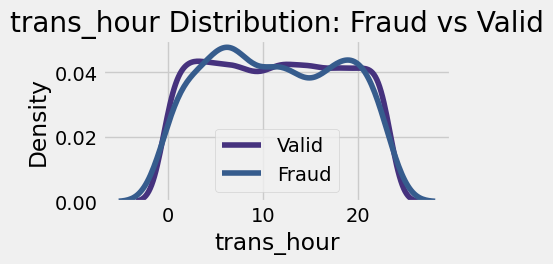

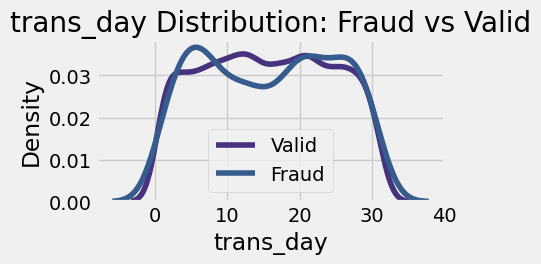

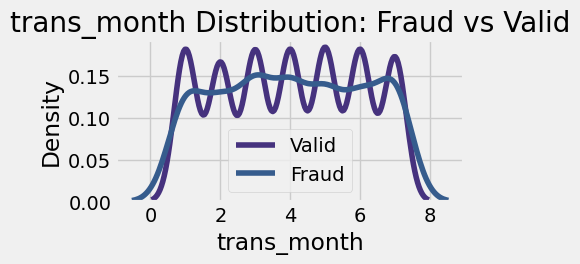

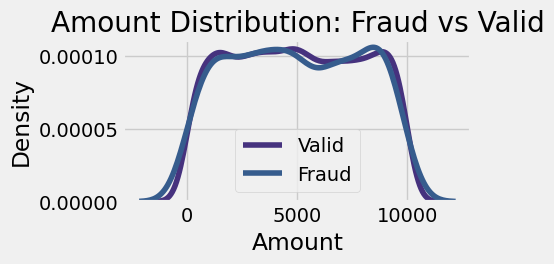

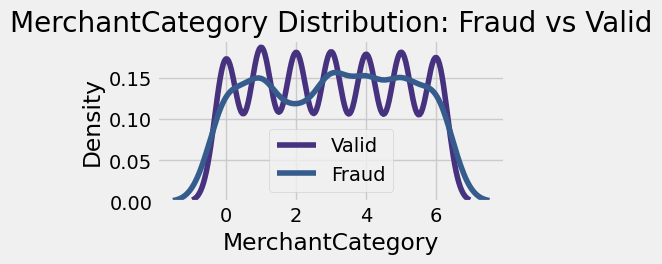

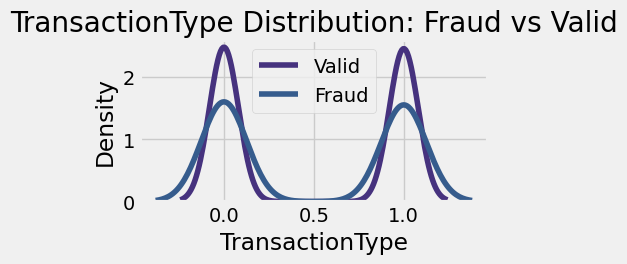

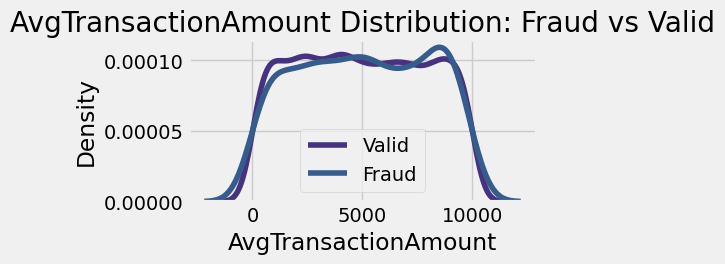

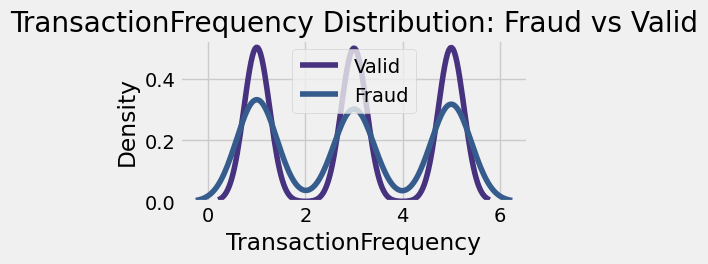

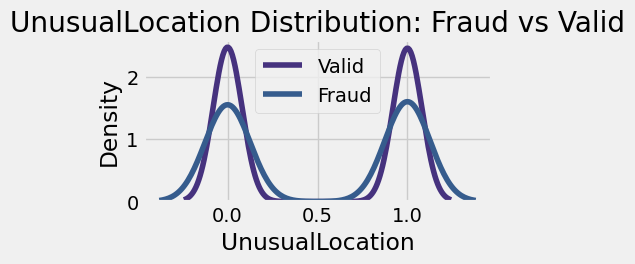

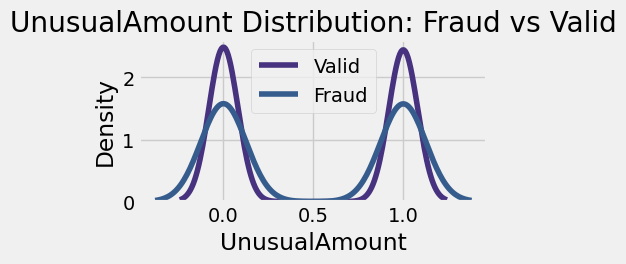

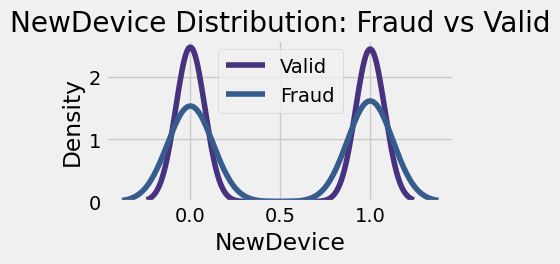

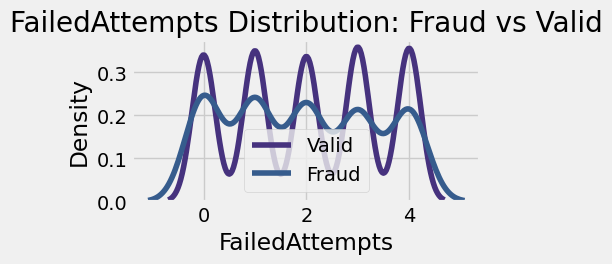

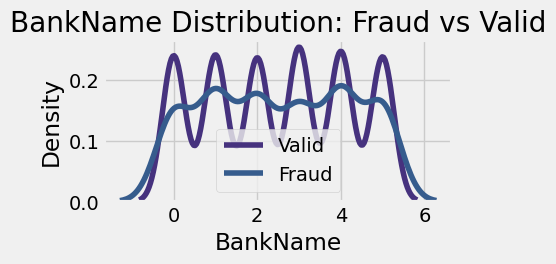

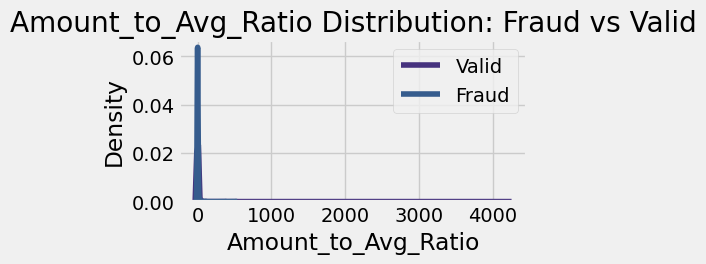

In [29]:
for col in dataset.columns:
    if col != 'FraudFlag':
        plt.figure(figsize=(4,2))
        sns.kdeplot(dataset[dataset['FraudFlag']==0][col], label='Valid')
        sns.kdeplot(dataset[dataset['FraudFlag']==1][col], label='Fraud')
        plt.title(f"{col} Distribution: Fraud vs Valid")
        plt.legend()
        plt.show()


Multivariate Analysis

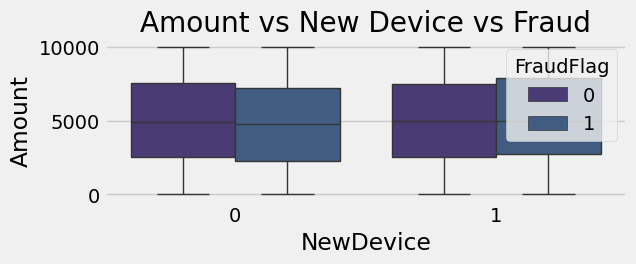

In [30]:
plt.figure(figsize=(6,2))
sns.boxplot(x='NewDevice', y='Amount', hue='FraudFlag', data=dataset)
plt.title("Amount vs New Device vs Fraud")
plt.show()


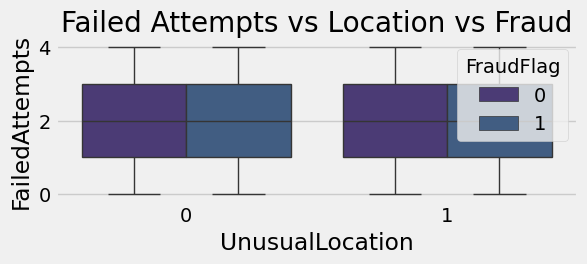

In [31]:
plt.figure(figsize=(6,2))
sns.boxplot(x='UnusualLocation', y='FailedAttempts', hue='FraudFlag', data=dataset)
plt.title("Failed Attempts vs Location vs Fraud")
plt.show()

Outlier Analysis

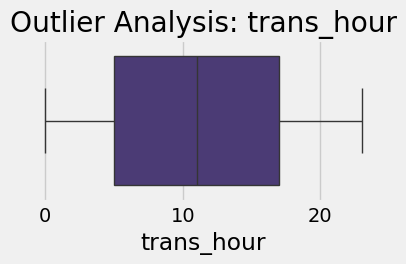

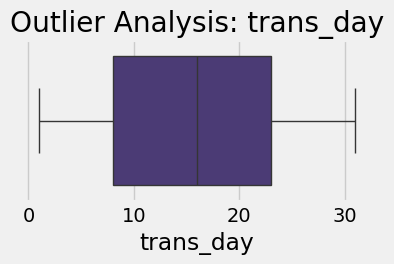

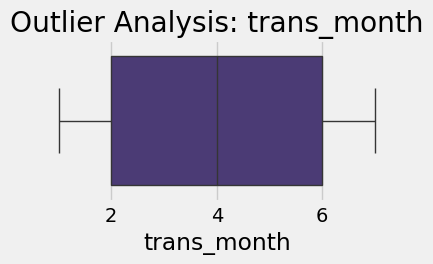

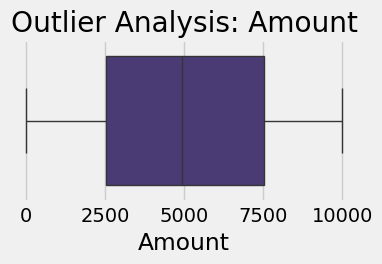

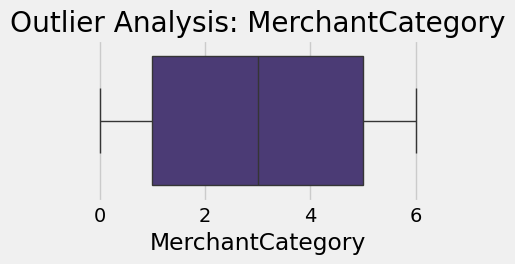

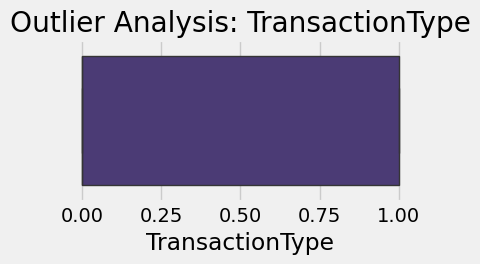

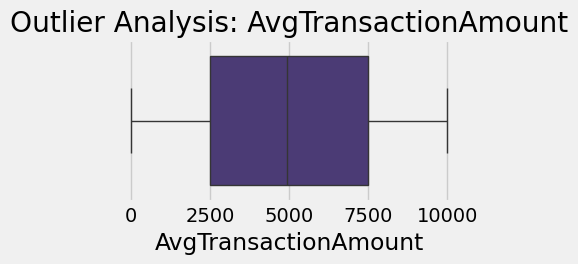

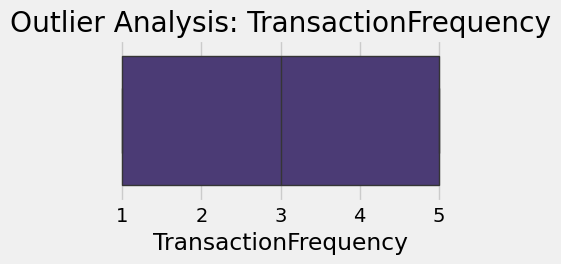

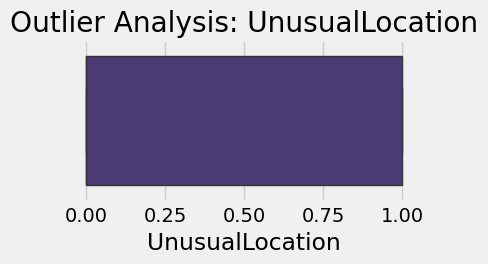

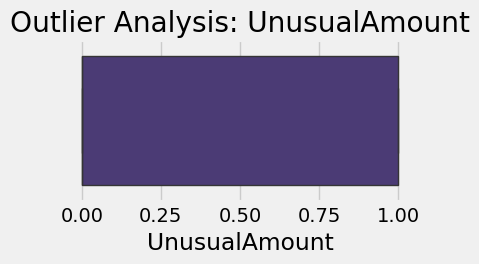

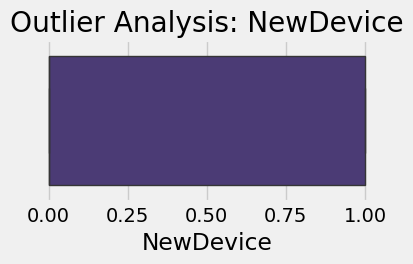

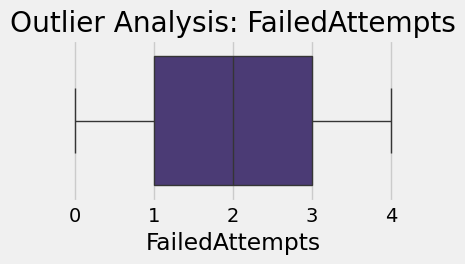

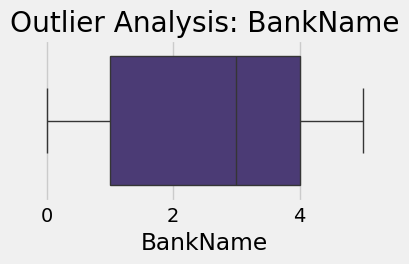

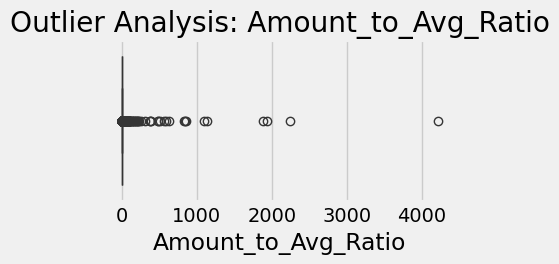

In [32]:
# Boxplots for numeric features
numeric_cols = dataset.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col != 'FraudFlag':
        plt.figure(figsize=(4,2))
        sns.boxplot(x=dataset[col])
        plt.title(f"Outlier Analysis: {col}")
        plt.show()


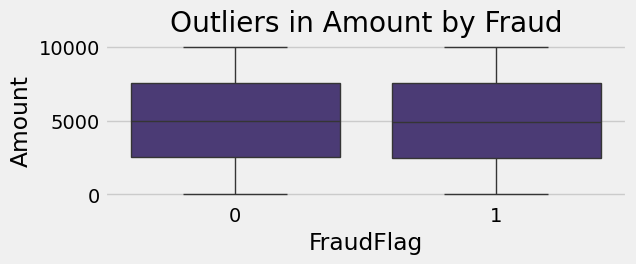

In [33]:
#Amount Outliers Specifically
plt.figure(figsize=(6,2))
sns.boxplot(x='FraudFlag', y='Amount', data=dataset)
plt.title("Outliers in Amount by Fraud")
plt.show()


Interaction Analysis Between Risk Indicators


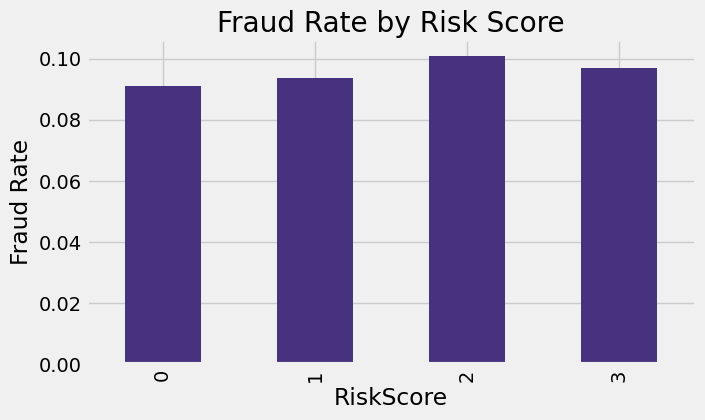

In [34]:
risk_features = ['UnusualLocation','UnusualAmount','NewDevice']

dataset['RiskScore'] = dataset[risk_features].sum(axis=1)

risk_fraud = dataset.groupby('RiskScore')['FraudFlag'].mean()

plt.figure(figsize=(7,4))
risk_fraud.plot(kind='bar')
plt.title("Fraud Rate by Risk Score")
plt.ylabel("Fraud Rate")
plt.show()


## Preliminary Feature Importance (Pre-Model)

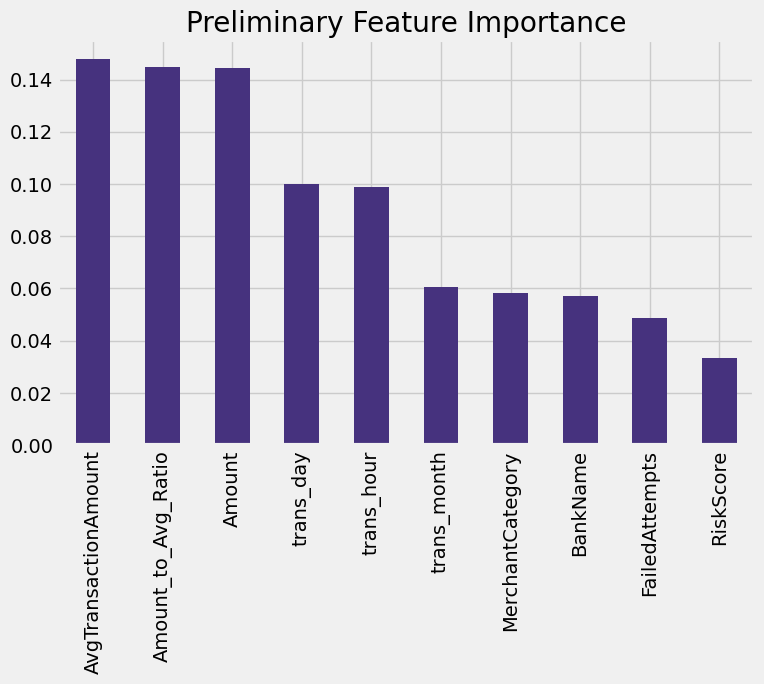

In [35]:
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop('FraudFlag', axis=1)
y = dataset['FraudFlag']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).plot(kind='bar')
plt.title("Preliminary Feature Importance")
plt.show()


In [36]:
# Top Features

In [37]:
top_features = importances.head(5)
print("Top Predictive Features:\n", top_features)

Top Predictive Features:
 AvgTransactionAmount    0.147703
Amount_to_Avg_Ratio     0.144619
Amount                  0.144273
trans_day               0.099822
trans_hour              0.098802
dtype: float64
